In [161]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
import datetime
import scipy.stats as stats
import plotly.express as px 
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import PowerTransformer,RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


In [162]:
# Info about column 

# key - a unique identifier for each trip
# fare_amount - the cost of each trip in usd
# pickup_datetime - date and time when the meter was engaged
# passenger_count - the number of passengers in the vehicle (driver entered value)
# pickup_longitude - the longitude where the meter was engaged
# pickup_latitude - the latitude where the meter was engaged
# dropoff_longitude - the longitude where the meter was disengaged
# dropoff_latitude - the latitude where the meter was disengaged

In [163]:
df = pd.read_csv('./csv/uber.csv')

In [164]:
df = df.drop(['Unnamed: 0','key'],axis=1)

In [165]:
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...
199995,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1


In [166]:
df.shape

(200000, 7)

In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   fare_amount        200000 non-null  float64
 1   pickup_datetime    200000 non-null  object 
 2   pickup_longitude   200000 non-null  float64
 3   pickup_latitude    200000 non-null  float64
 4   dropoff_longitude  199999 non-null  float64
 5   dropoff_latitude   199999 non-null  float64
 6   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 10.7+ MB


In [168]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [169]:
df.isna().mean()

fare_amount          0.000000
pickup_datetime      0.000000
pickup_longitude     0.000000
pickup_latitude      0.000000
dropoff_longitude    0.000005
dropoff_latitude     0.000005
passenger_count      0.000000
dtype: float64

In [170]:
#  Removed all negtive fare rows totao are 17 
negtive_column = df[df['fare_amount'] < 0 ].index
df = df.drop(negtive_column)

In [171]:
df = df.dropna(axis=0)

In [172]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])


In [173]:
df['year'] = df['pickup_datetime'].dt.year
df['month'] = df['pickup_datetime'].dt.month
df['Date'] = df['pickup_datetime'].dt.date
df['time'] = df['pickup_datetime'].dt.time

In [174]:
# if longitude and latitude are zero menas data is missing 
missing_loc =  df[(df['pickup_longitude'] == 0) & (df['pickup_latitude'] ==0 ) & (df['dropoff_longitude'] == 0) & (df['dropoff_latitude']  == 0)].index
df = df.drop(missing_loc,axis=0)

In [175]:
# u also need to check if pickup loc are not present then data is missing it is not usefull
# becouse pickup and drop locations are important we only  predect on the  bases of pickup loc and drop loc if u see  pickup location arer 0.0 and drop are drop are fill the means data is missing  
missing_pickup_loc = df[(df['pickup_latitude'] == 0) & (df['pickup_longitude'] == 0)].index
df = df.drop(missing_pickup_loc,axis=0)

In [176]:
# missing drop location are removed 
missing_dropoff_loc = df[(df['dropoff_latitude'] == 0) & (df['dropoff_longitude'] == 0)].index
df = df.drop(missing_dropoff_loc,axis=0)

In [177]:
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,Date,time
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,2015-05-07,19:52:06
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,2009-07-17,20:04:56
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,2009-08-24,21:45:00
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,2009-06-26,08:22:21
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,2014-08-28,17:47:00
...,...,...,...,...,...,...,...,...,...,...,...
199995,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,2012,10,2012-10-28,10:49:00
199996,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,2014,3,2014-03-14,01:09:00
199997,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,2009,6,2009-06-29,00:42:00
199998,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1,2015,5,2015-05-20,14:56:25


In [178]:
# count is userfull when u want to calculate how many rows are in one year 
df.groupby('year')['passenger_count'].sum()

year
2009    50813
2010    49736
2011    51868
2012    52799
2013    52501
2014    49840
2015    22806
Name: passenger_count, dtype: int64

In [179]:
# total pesenger book uber in 2009 to 15  are 330363
df['passenger_count'].sum()

np.int64(330363)

In [180]:
df.groupby('year')[['passenger_count','fare_amount']].sum()

,passenger_count,fare_amount
year,,
2009,50813,301931.69
2010,49736,299805.37
2011,51868,324818.17
2012,52799,353803.45
2013,52501,388318.89
2014,49840,380072.46
2015,22806,175306.52


In [181]:
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,Date,time
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,2015-05-07,19:52:06
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,2009-07-17,20:04:56
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,2009-08-24,21:45:00
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,2009-06-26,08:22:21
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,2014-08-28,17:47:00
...,...,...,...,...,...,...,...,...,...,...,...
199995,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,2012,10,2012-10-28,10:49:00
199996,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,2014,3,2014-03-14,01:09:00
199997,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,2009,6,2009-06-29,00:42:00
199998,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1,2015,5,2015-05-20,14:56:25


### Those month that get more passenger in every year

In [182]:
#which day uber get more pessenger ? and which month is usefull for uber
# and in weekend uber get more penseeenge to normla day ? In which time most pessenger book uber ?
# now i get which month is usefull which month uber get more passengers
# idxmax() use for when u want a column that value is high [gives the index (position) of the biggest value]
agg_dict = {
    'passenger_count':'sum'
}
group_data = df.groupby(['year','month'],as_index=False)['passenger_count'].sum()
result = group_data.loc[group_data.groupby('year')['passenger_count'].idxmax()]
result.sort_values(by='passenger_count',ascending=False)
# group_data.groupby('year')['passenger_count'].max()

,year,month,passenger_count
33,2011,10,4815
50,2013,3,4704
40,2012,5,4621
16,2010,5,4598
62,2014,3,4540
11,2009,12,4533
76,2015,5,4082


In [183]:
group_data.groupby('year')['passenger_count'].max()

year
2009    4533
2010    4598
2011    4815
2012    4621
2013    4704
2014    4540
2015    4082
Name: passenger_count, dtype: int64

In [184]:
group_data.groupby('year')['passenger_count'].idxmax()

year
2009    11
2010    16
2011    33
2012    40
2013    50
2014    62
2015    76
Name: passenger_count, dtype: int64

In [185]:
# in pickup some data is misssing like in latitude missing some time or some time longitude is missing 
pickup_l_m = df[df['pickup_latitude'] == 0].index
df = df.drop(pickup_l_m,axis=0)
# pickup longitude data is misssing
df = df.drop(df[df['pickup_longitude'] == 0].index,axis=0)
# drop location latude is wrong
df = df.drop(df[df['dropoff_latitude'] == 0].index,axis=0)
# drop location longtude
df = df.drop(df[df['dropoff_longitude'] == 0].index,axis=0)
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,Date,time
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,2015-05-07,19:52:06
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,2009-07-17,20:04:56
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,2009-08-24,21:45:00
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,2009-06-26,08:22:21
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,2014-08-28,17:47:00
...,...,...,...,...,...,...,...,...,...,...,...
199995,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,2012,10,2012-10-28,10:49:00
199996,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,2014,3,2014-03-14,01:09:00
199997,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,2009,6,2009-06-29,00:42:00
199998,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1,2015,5,2015-05-20,14:56:25


In [186]:
# in passenger_count some of a data is wrong where total pessenger are 208 i m going remove this data 
df = df.drop(df[df['passenger_count'] == 208].index,axis=0)

### NOw i need that week that get more passenger in week every year
 

In [187]:
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,Date,time
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,2015-05-07,19:52:06
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,2009-07-17,20:04:56
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,2009-08-24,21:45:00
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,2009-06-26,08:22:21
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,2014-08-28,17:47:00
...,...,...,...,...,...,...,...,...,...,...,...
199995,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,2012,10,2012-10-28,10:49:00
199996,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,2014,3,2014-03-14,01:09:00
199997,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,2009,6,2009-06-29,00:42:00
199998,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1,2015,5,2015-05-20,14:56:25


In [188]:
df['Month_End'] = df['pickup_datetime'].dt.is_month_end
df['Month_st'] = df['pickup_datetime'].dt.is_month_start

In [189]:
def week_of_month(x):
    return ((x-1) // 7 + 1)
df['week_of_month'] = df['pickup_datetime'].dt.day.apply(week_of_month)


In [190]:
prof = ProfileReport(df)
prof.to_file(output_file='output.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 14/14 [00:02<00:00,  4.69it/s]
/home/arman/miniconda3/envs/ml100-day/lib/python3.12/site-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[9 0 0 ... 0 9 1]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(
/home/arman/miniconda3/envs/ml100-day/lib/python3.12/site-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[3 5 6 ... 4 3 3]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [191]:
grouping_data = df.groupby(['year','month','week_of_month'],as_index=False)['passenger_count'].sum()

In [192]:
grouping_data

,year,month,week_of_month,passenger_count
0,2009,1,1,805
1,2009,1,2,930
2,2009,1,3,945
3,2009,1,4,997
4,2009,1,5,490
...,...,...,...,...
379,2015,6,1,950
380,2015,6,2,754
381,2015,6,3,796
382,2015,6,4,883


In [193]:
idx = grouping_data.groupby(['year','month'])['passenger_count'].idxmax()
result = grouping_data.loc[idx,['year','month','week_of_month','passenger_count']]
result

,year,month,week_of_month,passenger_count
3,2009,1,4,997
7,2009,2,3,1061
11,2009,3,3,1071
16,2009,4,3,987
21,2009,5,3,1092
...,...,...,...,...
362,2015,2,3,997
365,2015,3,2,990
369,2015,4,1,964
374,2015,5,1,1048


In [194]:
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,Date,time,Month_End,Month_st,week_of_month
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,2015-05-07,19:52:06,False,False,1
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,2009-07-17,20:04:56,False,False,3
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,2009-08-24,21:45:00,False,False,4
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,2009-06-26,08:22:21,False,False,4
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,2014-08-28,17:47:00,False,False,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,2012,10,2012-10-28,10:49:00,False,False,4
199996,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,2014,3,2014-03-14,01:09:00,False,False,2
199997,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,2009,6,2009-06-29,00:42:00,False,False,5
199998,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1,2015,5,2015-05-20,14:56:25,False,False,3


In [195]:
#### .size() show us num of items in data set
df.groupby('month')['fare_amount'].mean()

month
1     10.717033
2     10.925589
3     11.098708
4     11.303624
5     11.644130
6     11.602884
7     11.137358
8     11.196215
9     11.773336
10    11.713219
11    11.613668
12    11.467714
Name: fare_amount, dtype: float64

In [196]:
# distance based analysis 
result = df.groupby(['pickup_longitude','pickup_latitude'],as_index=False)['passenger_count'].count()
result[result['passenger_count'] > 1]

,pickup_longitude,pickup_latitude,passenger_count
22,-74.689831,40.190564,7
273,-74.023050,40.765990,3
2706,-74.012810,40.717668,3
10040,-74.006817,40.730812,2
10249,-74.006721,40.730495,2
...,...,...,...
195040,-73.776968,40.646255,2
195274,-73.776750,40.645387,2
195329,-73.776730,40.645332,2
195362,-73.776720,40.645230,2


In [197]:
df[(df['pickup_longitude'] == -74.689830775147)  & (df['pickup_latitude'] == 40.190563553444)]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,Date,time,Month_End,Month_st,week_of_month
696,5.3,2011-02-05 17:52:56+00:00,-74.689831,40.190564,-74.689831,40.190564,1,2011,2,2011-02-05,17:52:56,False,False,1
15702,18.9,2011-04-19 09:52:35+00:00,-74.689831,40.190564,-74.689831,40.190564,3,2011,4,2011-04-19,09:52:35,False,False,3
43500,16.5,2011-04-29 21:43:07+00:00,-74.689831,40.190564,-74.689831,40.190564,1,2011,4,2011-04-29,21:43:07,False,False,5
105306,4.9,2011-03-05 18:01:06+00:00,-74.689831,40.190564,-74.689831,40.190564,2,2011,3,2011-03-05,18:01:06,False,False,1
112794,4.9,2011-02-13 03:53:55+00:00,-74.689831,40.190564,-74.689831,40.190564,2,2011,2,2011-02-13,03:53:55,False,False,2
171891,9.7,2011-02-07 08:43:15+00:00,-74.689831,40.190564,-74.689831,40.190564,2,2011,2,2011-02-07,08:43:15,False,False,1
185083,10.9,2011-03-12 01:11:37+00:00,-74.689831,40.190564,-74.689831,40.190564,1,2011,3,2011-03-12,01:11:37,False,False,2


In [198]:
df['pickup_hour'] = df['pickup_datetime'].dt.hour

In [199]:
# you can see passenger are increasing when time  6 to 10 in night 
df.groupby('pickup_hour')['passenger_count'].count()

pickup_hour
0      7688
1      5785
2      4330
3      3188
4      2314
5      1923
6      4056
7      7085
8      8903
9      9157
10     8785
11     9234
12     9745
13     9821
14     9587
15     9412
16     8128
17     9535
18    11839
19    12359
20    11514
21    11225
22    10803
23     9598
Name: passenger_count, dtype: int64

In [200]:
# claculate distance for location 
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,Date,time,Month_End,Month_st,week_of_month,pickup_hour
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,2015-05-07,19:52:06,False,False,1,19
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,2009-07-17,20:04:56,False,False,3,20
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,2009-08-24,21:45:00,False,False,4,21
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,2009-06-26,08:22:21,False,False,4,8
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,2014-08-28,17:47:00,False,False,4,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,2012,10,2012-10-28,10:49:00,False,False,4,10
199996,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,2014,3,2014-03-14,01:09:00,False,False,2,1
199997,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,2009,6,2009-06-29,00:42:00,False,False,5,0
199998,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1,2015,5,2015-05-20,14:56:25,False,False,3,14


####  Haversine  Formula
###### 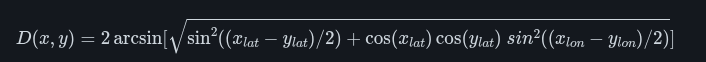

In [201]:
''' Haversine  Formula to calulate  loc in km -> 
''' 

pickup_loc = [40.73835372924805,-73.99981689453125] # latitude , lon
drop_loc = [40.72321701049805,-73.99951171875]

def haversine_formula(p_latitude,p_longitude,d_latitude,d_longitude):
    # !step  to convert degree into randians 
    p_lat_r = np.radians(p_latitude)
    p_lon_r  = np.radians(p_longitude)
    d_lat_r = np.radians(d_latitude)
    d_lon_r = np.radians(d_longitude)
                         
    # Step 2 Find diffrence between pic loc and drop loc we use here radians values 
    latitude_diff = d_lat_r - p_lat_r 
    longitude_diff = d_lon_r - p_lon_r

    # Step 3 use fomula Here a
    a = np.sin(latitude_diff/2)**2 + np.cos(p_latitude)*np.cos(d_latitude)*(np.sin(longitude_diff/2)**2)

    print(a[5])
    #step 4 find c 
    a_sqrt = np.sqrt(a)
    c = 2 * np.arcsin(a_sqrt)
    #step 5 now use eart radius in km is 6371
    earth_r = 6371
    
    return earth_r * c

In [202]:
# pic_loc_radian
# latitude_diff
df['distance_in_km'] = haversine_formula(df['pickup_latitude'],df['pickup_longitude'],df['dropoff_latitude'],df['dropoff_longitude'])

0.0


/home/arman/miniconda3/envs/ml100-day/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [203]:
# drop_loc_radian
# longitude_diff
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,Date,time,Month_End,Month_st,week_of_month,pickup_hour,distance_in_km
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,2015-05-07,19:52:06,False,False,1,19,1.683464
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,2009-07-17,20:04:56,False,False,3,20,2.457722
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,2009-08-24,21:45:00,False,False,4,21,5.891616
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,2009-06-26,08:22:21,False,False,4,8,1.837112
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,2014-08-28,17:47:00,False,False,4,17,5.654758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,2012,10,2012-10-28,10:49:00,False,False,4,10,0.118175
199996,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,2014,3,2014-03-14,01:09:00,False,False,2,1,2.447564
199997,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,2009,6,2009-06-29,00:42:00,False,False,5,0,15.722967
199998,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1,2015,5,2015-05-20,14:56:25,False,False,3,14,3.675076


In [204]:
df = df.drop(df[df['distance_in_km'] == 0].index,axis=0)

In [205]:
# now we get ans
df['distance_in_km'] = np.round(df['distance_in_km'],3)

In [206]:
#make better code that use function
np.round(1.2323222, 4)

np.float64(1.2323)

In [207]:
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,Date,time,Month_End,Month_st,week_of_month,pickup_hour,distance_in_km
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,2015-05-07,19:52:06,False,False,1,19,1.683
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,2009-07-17,20:04:56,False,False,3,20,2.458
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,2009-08-24,21:45:00,False,False,4,21,5.892
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,2009-06-26,08:22:21,False,False,4,8,1.837
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,2014-08-28,17:47:00,False,False,4,17,5.655
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,2012,10,2012-10-28,10:49:00,False,False,4,10,0.118
199996,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,2014,3,2014-03-14,01:09:00,False,False,2,1,2.448
199997,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,2009,6,2009-06-29,00:42:00,False,False,5,0,15.723
199998,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1,2015,5,2015-05-20,14:56:25,False,False,3,14,3.675


In [208]:
prof = ProfileReport(df)
prof.to_file(output_file='output.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:02<00:00,  6.85it/s]
/home/arman/miniconda3/envs/ml100-day/lib/python3.12/site-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[9 0 0 ... 0 9 1]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(
/home/arman/miniconda3/envs/ml100-day/lib/python3.12/site-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[3 5 6 ... 4 3 3]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(
/home/arman/miniconda3/envs/ml100-day/lib/python3.12/site-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Setting 

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [209]:
print(df['pickup_hour'].unique())

[19 20 21  8 17  7  9 14 11 22 23  0  2 16  6 15  5 10 18 13  3  1  4 12]


In [210]:
#Wrong Data in fare
# w_data = [,df[(df['fare_amount'] == 499)  ].index]
df = df.drop(df[df['fare_amount'] == 220 ].index,axis=0)
df = df.drop(df[df['fare_amount'] == 499 ].index,axis=0)
df = df.drop(df[df['fare_amount'] == 0.0 ].index,axis=0)

# w_data

In [211]:
# ploting distance, passemger_count , 
df = df.drop(df[df['passenger_count'] == 0 ].index,axis=0)

In [212]:
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,Date,time,Month_End,Month_st,week_of_month,pickup_hour,distance_in_km
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,2015-05-07,19:52:06,False,False,1,19,1.683
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,2009-07-17,20:04:56,False,False,3,20,2.458
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,2009-08-24,21:45:00,False,False,4,21,5.892
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,2009-06-26,08:22:21,False,False,4,8,1.837
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,2014-08-28,17:47:00,False,False,4,17,5.655
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,2012,10,2012-10-28,10:49:00,False,False,4,10,0.118
199996,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,2014,3,2014-03-14,01:09:00,False,False,2,1,2.448
199997,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,2009,6,2009-06-29,00:42:00,False,False,5,0,15.723
199998,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1,2015,5,2015-05-20,14:56:25,False,False,3,14,3.675


#### DATA Cleaning in distance and fare data 

In [213]:
df= df.drop(df[df['distance_in_km'].isna()].index,axis=0)

In [214]:
df = df.drop(df[(df['distance_in_km'] > 100) & (df['distance_in_km'] < 200 )].index,axis=0)

In [215]:
df = df.drop(df[df['distance_in_km'] >= 200 ].index,axis=0)

In [216]:
df = df.drop(df[(df['distance_in_km'] >= 50) & (df['fare_amount'] <=  50 )].index, axis=0)

In [217]:
df['fare_amount'].max()

np.float64(230.0)

In [218]:
df= df.drop(df[(df['fare_amount'] >= 100) & (df['distance_in_km'] <= 10)].index, axis=0)

In [219]:
df = df.drop(df[(df['fare_amount'] <= 2 ) & ( df['distance_in_km'] > 1)].index,axis=0)

In [220]:
df[(df['distance_in_km'] < 1) & (df['fare_amount'] > 20)] 

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,Date,time,Month_End,Month_st,week_of_month,pickup_hour,distance_in_km
427,49.57,2010-07-04 17:10:17+00:00,-73.787044,40.641077,-73.786471,40.641836,1,2010,7,2010-07-04,17:10:17,False,False,1,17,0.105
1531,50.00,2009-05-28 19:40:00+00:00,-73.977602,40.782908,-73.977603,40.782908,1,2009,5,2009-05-28,19:40:00,False,False,4,19,0.000
1697,45.00,2009-09-18 15:09:00+00:00,-73.790162,40.646833,-73.790158,40.646833,6,2009,9,2009-09-18,15:09:00,False,False,3,15,0.000
1750,45.00,2010-05-31 07:47:28+00:00,-73.980222,40.764240,-73.979875,40.764180,1,2010,5,2010-05-31,07:47:28,True,False,5,7,0.039
1964,20.50,2012-01-23 09:33:46+00:00,-74.010278,40.709343,-74.008735,40.707463,1,2012,1,2012-01-23,09:33:46,False,False,4,9,0.269
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198547,40.00,2012-05-04 07:38:00+00:00,-73.872810,40.774395,-73.872808,40.774397,1,2012,5,2012-05-04,07:38:00,False,False,1,7,0.000
198655,52.00,2014-08-31 20:02:06+00:00,-73.789883,40.647023,-73.789882,40.647023,1,2014,8,2014-08-31,20:02:06,True,False,5,20,0.000
199007,28.50,2012-09-28 08:08:53+00:00,-73.952870,40.786344,-73.952833,40.785960,1,2012,9,2012-09-28,08:08:53,False,False,4,8,0.043
199635,20.90,2011-03-05 13:08:00+00:00,-73.905370,40.741812,-73.905950,40.742342,2,2011,3,2011-03-05,13:08:00,False,False,1,13,0.087


In [221]:
df = df.drop(df[df['distance_in_km'] == 0 ].index,axis=0)

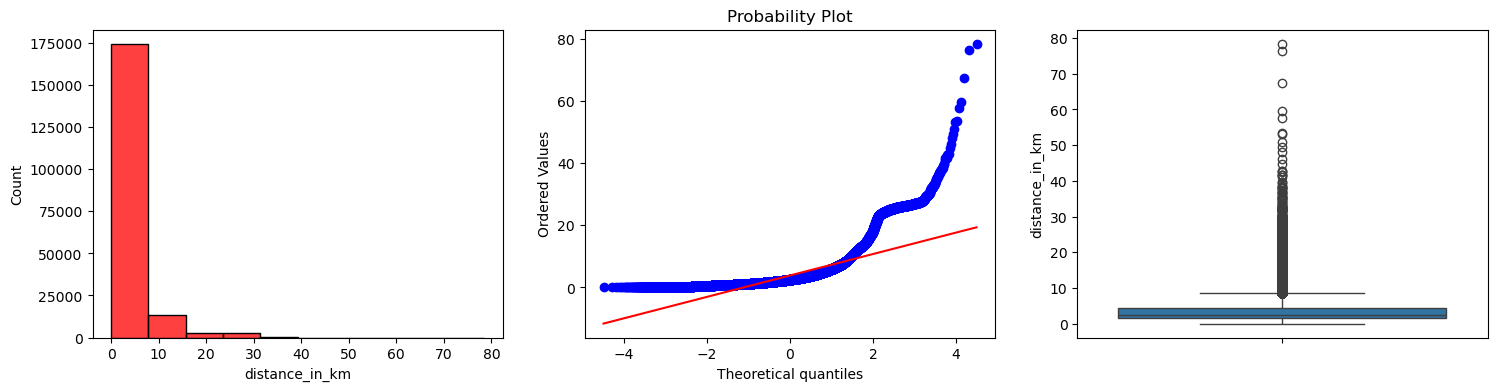

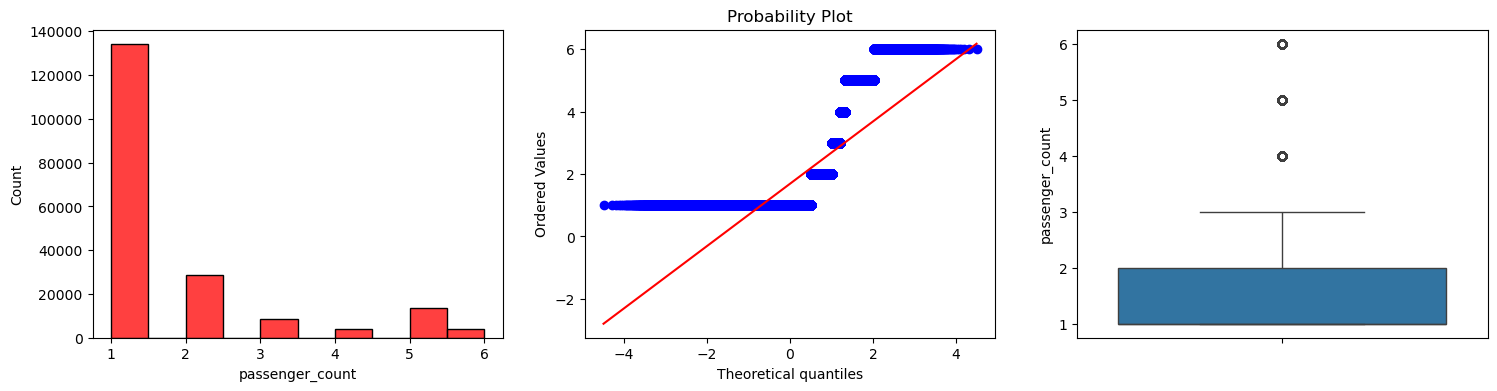

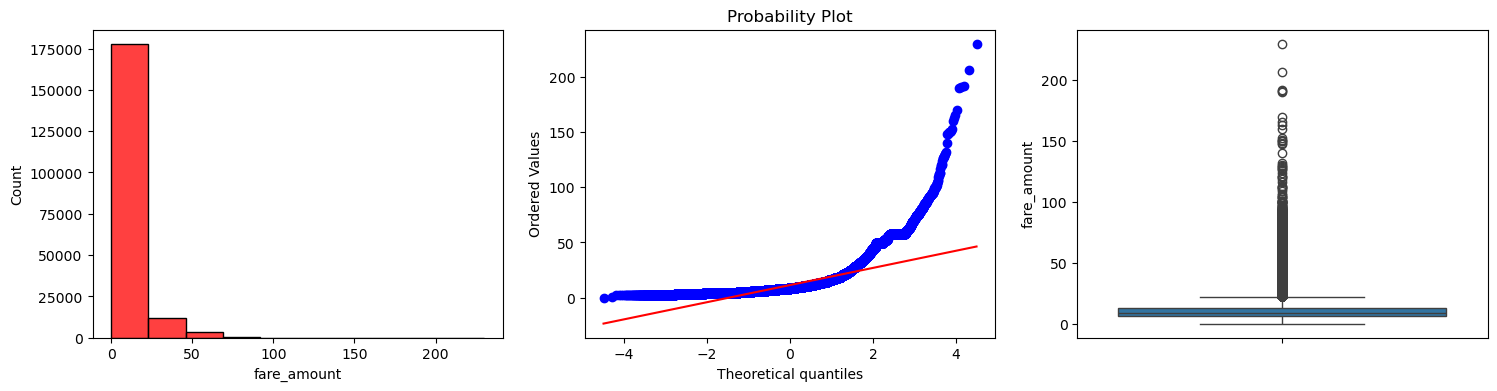

In [222]:
cols_plt = df[['distance_in_km','passenger_count','fare_amount']]
for cols in cols_plt.columns:
    plt.figure(figsize=(18,4))
    
    plt.subplot(131)
    sns.histplot(df[cols],bins=10,color='red')
    # plt.title(f'{df[cols]}')

    plt.subplot(132)
    stats.probplot(df[cols],plot=plt)
    # plt.title(f'{df[cols]}')
    
    plt.subplot(133)
    sns.boxplot(df[cols])
    # plt.title(f'{df[cols]}')
    
    plt.show()

In [223]:
x = df[['passenger_count','pickup_hour','distance_in_km']]
y =  df['fare_amount']
x_train , x_test , y_train , y_test = train_test_split(x,y , test_size=0.3,random_state=42)

In [224]:
x_train

,passenger_count,pickup_hour,distance_in_km
171774,2,23,23.081
122005,1,0,1.866
117528,1,12,4.865
51663,1,9,4.070
98605,1,20,1.261
...,...,...,...
124211,2,8,2.732
107430,1,14,2.414
136681,2,0,19.351
152170,1,23,0.580


In [225]:
y_train

171774    61.5
122005     8.0
117528    13.3
51663      8.1
98605      5.7
          ... 
124211    13.0
107430     8.5
136681    41.3
152170     3.7
126367    12.1
Name: fare_amount, Length: 135145, dtype: float64

In [226]:
x_train.shape

(135145, 3)

In [227]:
x_test.shape

(57920, 3)

In [228]:
#preprocessing 
Data = Pipeline([
    ("missing_data",SimpleImputer(strategy='mean')),
    ('Normal_distribute',PowerTransformer()),
    ('Scaling_data',RobustScaler())
])

In [229]:
preprocessing = ColumnTransformer(transformers=[
    ("preprocessing",Data, x_train.columns)
])

In [230]:
pip = Pipeline([
    ('preprocessing',preprocessing),
    ('modeal',LinearRegression())
])

In [ ]:
# ravel covert matricx into 1 d  we convert y_train into array then covert the shape of 3,1 sk learn only get 2d arraty that's the reason we chanage 
y_transform = PowerTransformer()
y_train_trans = y_transform.fit_transform(y_train.to_numpy().reshape(-1,1)).ravel()

In [ ]:
# y_transform = np.log1p(y_train)

In [257]:
pip.fit(x_train,y_train_trans)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('modeal', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('preprocessing', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [ ]:
y_pred_trans = pip.predict(x_test)
# we need to convert back ans into real data becouse modeal learned on the bases of transformed data 
# "The model learns from transformed data, so it also gives predictions in transformed form. That’s why we convert it back to the original scale."
y_pred = y_transform.inverse_transform(y_pred_trans.reshape(-1,1)).ravel()

In [261]:
r2_score(y_test,y_pred)

0.7223654255289309

In [240]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 135145 entries, 171774 to 126367
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   passenger_count  135145 non-null  int64  
 1   pickup_hour      135145 non-null  int32  
 2   distance_in_km   135145 non-null  float64
dtypes: float64(1), int32(1), int64(1)
memory usage: 3.6 MB


In [235]:
y_train

171774    61.5
122005     8.0
117528    13.3
51663      8.1
98605      5.7
          ... 
124211    13.0
107430     8.5
136681    41.3
152170     3.7
126367    12.1
Name: fare_amount, Length: 135145, dtype: float64

In [267]:
p_ans = pd.DataFrame(y_pred,columns=['fare_amount'])

In [271]:
p_ans

,fare_amount
0,6.779312
1,7.553871
2,7.417022
3,10.933775
4,14.792438
...,...
57915,7.789261
57916,13.691894
57917,13.440433
57918,5.600020


In [272]:
p_ans['fare_amount_2'] = y_test

In [273]:
p_ans

,fare_amount,fare_amount_2
0,6.779312,7.5
1,7.553871,NaN
2,7.417022,NaN
3,10.933775,NaN
4,14.792438,NaN
...,...,...
57915,7.789261,NaN
57916,13.691894,NaN
57917,13.440433,NaN
57918,5.600020,4.9


114700     8.1
17869     10.0
95172      7.0
148303    14.5
137750    26.5
          ... 
197269     9.5
79845     12.1
45547     70.0
41994      5.5
93064     56.8
Name: fare_amount, Length: 57920, dtype: float64